# Indian Personal Finance: Exploratory Data Analysis

* **Dataset** - Indian Personal Finance & Spending Habits (20,000 synthetic records)
* **Author** - Ankit
* **Date** - 4 May 2026


##### Project overview
This notebook explores spending patterns, saving habits, and the financial gap among Indian households using synthetic data that mimics broad real-world trends.

##### Notebook flow
1. Load and inspect the data
2. Clean the dataset and engineer savings metrics
3. Summarize the main patterns by segment
4. Visualize the spending and savings behavior
5. Wrap up with the key takeaways

**Tools Used**: Python, Matplotlib, Seaborn, Plotly

## Step 1: Load and inspect the data
Read the dataset, check the schema, and understand the columns before cleaning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px # For interactive plots
from scipy import stats


import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # to silence the categorial feature
warnings.filterwarnings('ignore', category=RuntimeWarning)


In [2]:
df = pd.read_csv('data.csv')


# General info
print('Dataset Shape:', df.shape,'\n')
print('Columns:')
print(df.columns.tolist(),'\n')
print('Missing Values & Data types:')
print(df.info(),'\n')
print('Stats:')
print(df.describe())


Dataset Shape: (20000, 27) 

Columns:
['Income', 'Age', 'Dependents', 'Occupation', 'City_Tier', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous', 'Desired_Savings_Percentage', 'Desired_Savings', 'Disposable_Income', 'Potential_Savings_Groceries', 'Potential_Savings_Transport', 'Potential_Savings_Eating_Out', 'Potential_Savings_Entertainment', 'Potential_Savings_Utilities', 'Potential_Savings_Healthcare', 'Potential_Savings_Education', 'Potential_Savings_Miscellaneous'] 

Missing Values & Data types:
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Income                           20000 non-null  float64
 1   Age                              20000 non-null  int64  
 2   Dependents                       20000 n

## Step 2: Clean and engineer features
Convert columns to numeric types, build expense totals, and derive savings metrics.


In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076


In [4]:
# Handle issues
df = df.copy()

# convert numeric where needed
numeric_cols = [
    'Income', 'Age', 'Dependents', 'Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment',	'Utilities',	'Healthcare',	'Education',	'Miscellaneous', 'Desired_Savings_Percentage',	'Desired_Savings',	'Disposable_Income'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Total Expense
expense_cols = [
    'Rent',	'Loan_Repayment',	'Insurance'	,'Groceries','Transport',	'Eating_Out',	'Entertainment',	'Utilities',	'Healthcare',	'Education',	'Miscellaneous'
    ]
df['Total_Expenses'] = df[expense_cols].sum(axis=1)

# Actual Saving Rate and Gap in savings
df['Actual Savings'] = df['Income'] - df['Total_Expenses']
df['Actual Savings Rate'] = df['Actual Savings'] / df['Income'] * 100

#Gap in Saving (Desired - Actual)
df['Savings_Gap'] = df['Desired_Savings'] - df['Actual Savings']

#Check outliers
print('Check outliers:')
for col in numeric_cols:
    if col in df.columns:
        q1,q3 = df[col].quantile([0.25, 0.75])
        IQR = q3 - q1
        outliers = ((df[col] < (q1 - 1.5*IQR)) | (df[col] > (q3 + 1.5*IQR))).sum()
        print(f"{col}: has {outliers} outliers")

# Drop rows with negative savings or invalid ages if any
df = df[(df['Age'] >= 18) & (df['Age'] <= 100) & (df['Actual Savings'] > 0)]

#cleaned Shape
print('Cleaned Shape:\n', df.shape)


Check outliers:
Income: has 1254 outliers
Age: has 0 outliers
Dependents: has 0 outliers
Rent: has 1320 outliers
Loan_Repayment: has 1880 outliers
Insurance: has 1375 outliers
Groceries: has 1227 outliers
Transport: has 1261 outliers
Eating_Out: has 1325 outliers
Entertainment: has 1324 outliers
Utilities: has 1291 outliers
Healthcare: has 1294 outliers
Education: has 1159 outliers
Miscellaneous: has 1348 outliers
Desired_Savings_Percentage: has 789 outliers
Desired_Savings: has 1303 outliers
Disposable_Income: has 1331 outliers
Cleaned Shape:
 (19888, 31)


## Step 3: Descriptive analysis
Summarize income, expense, and savings patterns across key segments.


In [5]:
#Exploratory Analysis
# Basic Stats by Demographics
print('Income by city Tier:')
print(df.groupby('City_Tier')['Income'].agg(['mean', 'median', 'count' ]).round(2))

print("\nAverage Expenses by Occupation (Top 5):")
occupation_exp = df.groupby('Occupation')['Total_Expenses'].mean().sort_values(ascending=False).head()
print(occupation_exp.round(2))

print("\nSavings Gap Summary:")
df['Savings_Gap'].describe()

Income by city Tier:
               mean    median  count
City_Tier                           
Tier_1     40980.85  29716.17   5822
Tier_2     41713.21  30418.68  10068
Tier_3     42031.39  30154.26   3998

Average Expenses by Occupation (Top 5):
Occupation
Professional     31173.38
Self_Employed    31082.54
Student          30966.13
Retired          30185.36
Name: Total_Expenses, dtype: float64

Savings Gap Summary:


count    1.988800e+04
mean    -5.700804e+03
std      5.753831e+03
min     -1.683383e+05
25%     -7.839518e+03
50%     -4.217217e+03
75%     -1.925868e+03
max      8.731149e-11
Name: Savings_Gap, dtype: float64

## Step 4: Visual exploration
Use charts to compare age groups, city tiers, expense mix, and savings behavior.


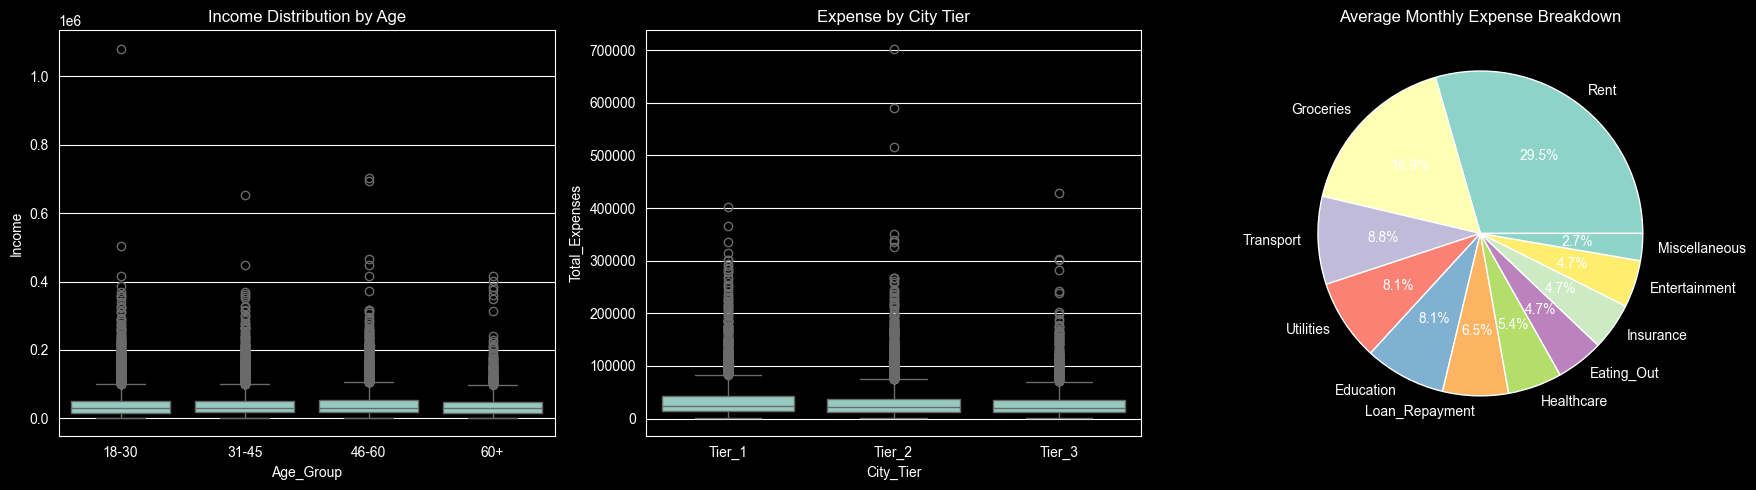

In [6]:
# income distribution by age
df['Age_Group'] = pd.cut(df['Age'], bins=[18,30,45,60,100], labels=['18-30', '31-45', '46-60', '60+'])
fig, axes = plt.subplots(1, 3 , figsize=(18,5))

sns.boxplot(x='Age_Group', y='Income', data=df, ax=axes[0])
axes[0].set_title('Income Distribution by Age')

# Expense distribution by city tier
sns.boxplot(x='City_Tier', y='Total_Expenses', data=df, ax=axes[1])
axes[1].set_title('Expense by City Tier')


# Expense breakdown Pie chart
avg_expenses = df[expense_cols].mean().sort_values(ascending=False)
axes[2].pie(avg_expenses.values, labels=avg_expenses.index, autopct='%1.1f%%')
axes[2].set_title('Average Monthly Expense Breakdown')


plt.tight_layout()
plt.show()


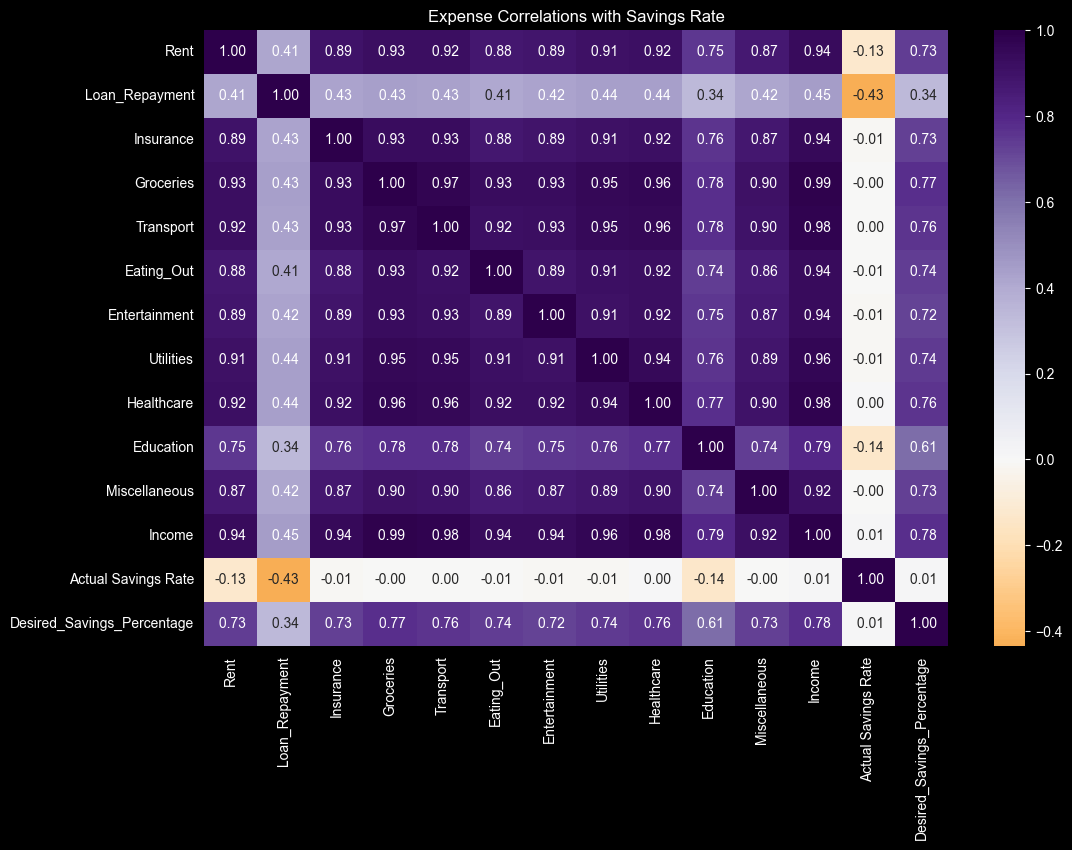

In [7]:
# Heatmaps: Correlation between Expenses & Savings
corr_cols = expense_cols + ['Income', 'Actual Savings Rate', 'Desired_Savings_Percentage']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='PuOr', center=0, fmt=' .2f')
plt.title('Expense Correlations with Savings Rate')
plt.show()

In [8]:
# Prepare data for Scatter(Sample & filter)
scatter_df = df[df['Actual Savings'] >= 0].copy() # To remove negative savings
scatter_df = scatter_df.sample(n=5000, random_state=42)  # Random sample for clarity (change n if you want more/less)

# Enhanced Interactive Scatter
fig = px.scatter(
    scatter_df,
    x='Income'
)

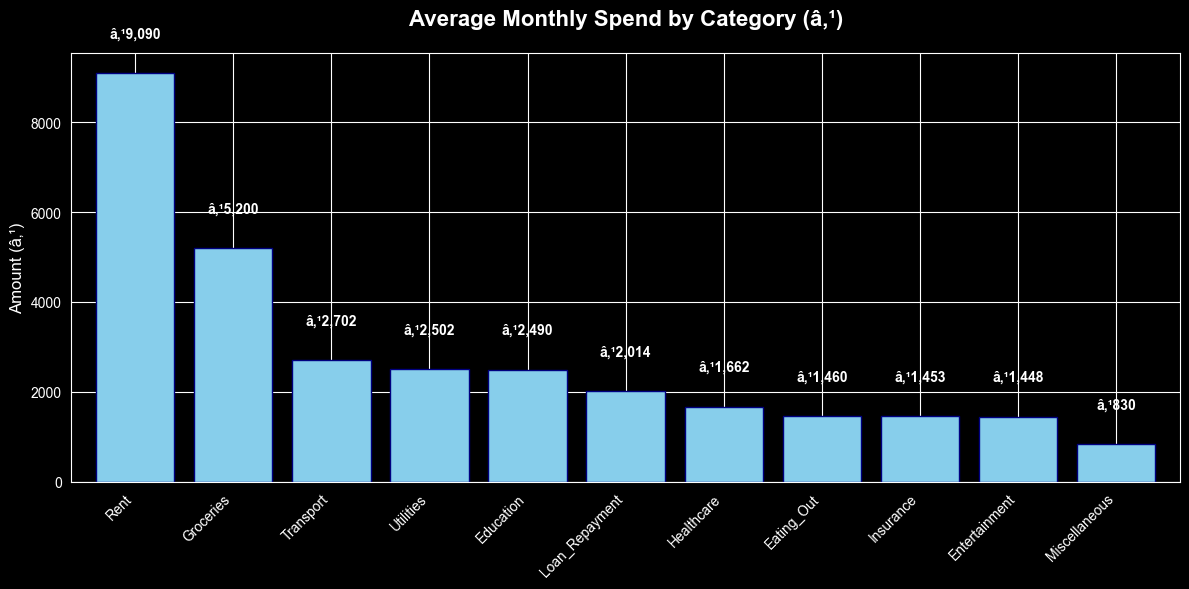

In [9]:
# Average Monthly Spend by Category

avg_exp = df[[col for col in df.columns if col in expense_cols]].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_exp.plot(kind='bar', color='skyblue', edgecolor='navy', width=0.8)
plt.title('Average Monthly Spend by Category (â‚¹)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Amount (â‚¹)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(avg_exp):
    plt.text(i, v + 800,  f'â‚¹{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

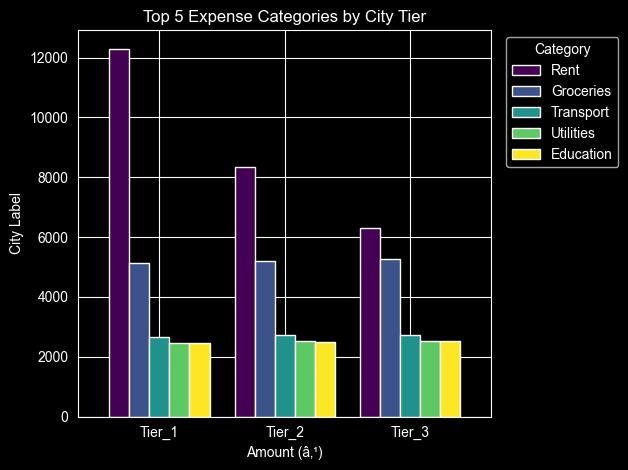

In [10]:
# Top 5 Expenses by City Tier

top_cat5 = avg_exp.head(5).index
city_exp = df.groupby('City_Tier', observed=True)[top_cat5].mean()

plt.figure(figsize=(12,6))
city_exp.plot(kind='bar', cmap='viridis', width=0.8)
plt.title('Top 5 Expense Categories by City Tier')
plt.xlabel('Amount (â‚¹)')
plt.ylabel('City Label')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

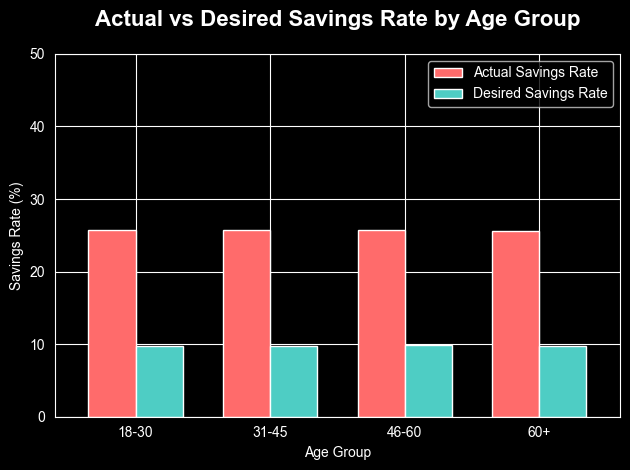

In [11]:
# Saving vs Desired Rate by Age Group

saving_by_age = df.groupby('Age_Group')[['Actual Savings Rate', 'Desired_Savings_Percentage']].mean()

plt.figure(figsize=(12,6))
saving_by_age.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], width=0.7)
plt.title('Actual vs Desired Savings Rate by Age Group', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Savings Rate (%)')
plt.xlabel('Age Group')
plt.legend(['Actual Savings Rate', 'Desired Savings Rate'])
plt.xticks(rotation=0)
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

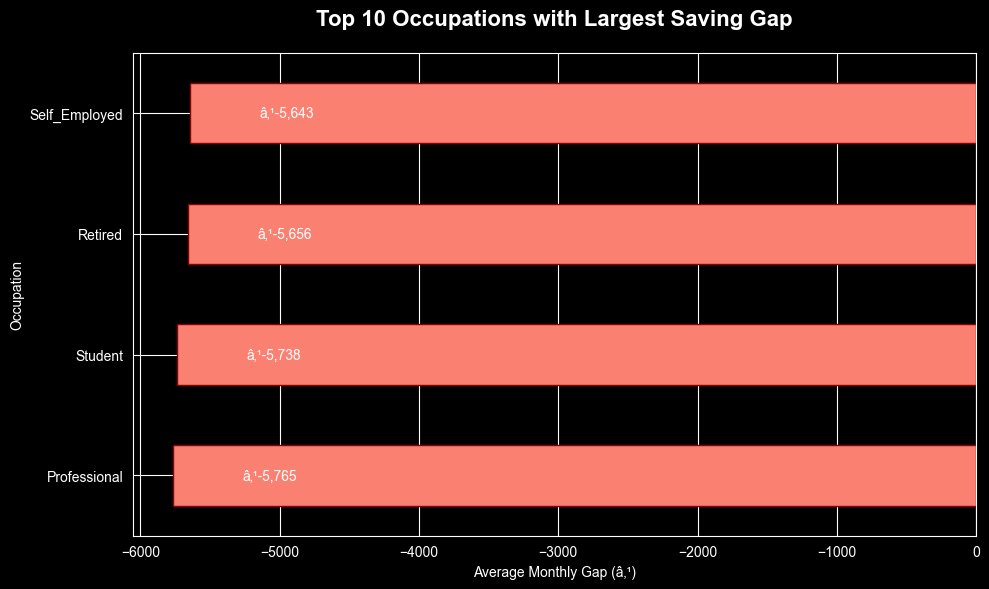

In [12]:
# Occupation with Largest Saving Gap (Top 10)

occ_by_gap = df.groupby('Occupation', observed=True)['Savings_Gap'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
occ_by_gap.plot(kind='barh', color='salmon', edgecolor='darkred')

plt.title('Top 10 Occupations with Largest Saving Gap', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Monthly Gap (â‚¹)')

for i, v in enumerate(occ_by_gap):
    plt.text(v + 500, i, f'â‚¹{v:,.0f}', va='center', fontsize=10)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


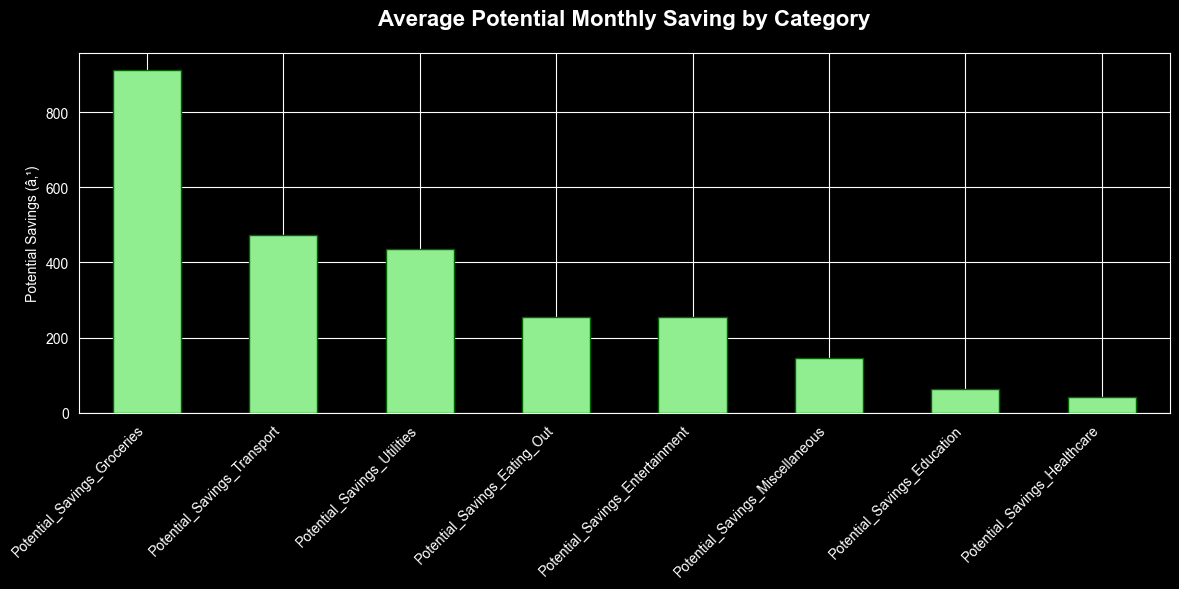

In [13]:
# Potential Savings Opportunities(if columns exists)
potential_col = [col for col in df.columns if "Potential" in col]

if len(potential_col) > 0:
    plt.figure(figsize=(12,6))
    df[potential_col].mean().sort_values(ascending=False).plot(kind='bar', color='lightgreen', edgecolor='darkgreen')
    plt.title('Average Potential Monthly Saving by Category', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Potential Savings (â‚¹)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No "Potential" Saving columns found')

## Step 5: Conclusion dashboard
Bring the main insights together in a compact view.


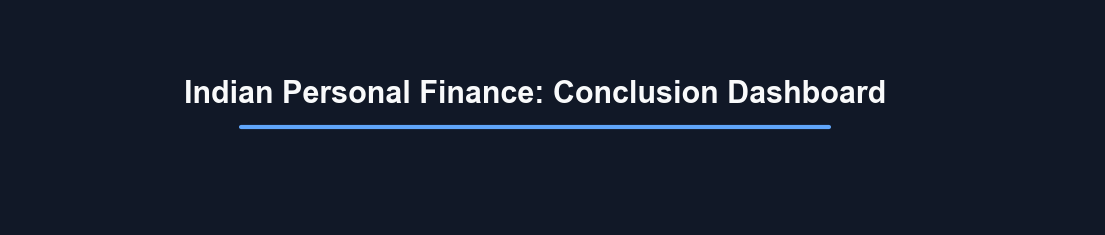

In [16]:
# 9. Key Takeaways Dashboard
fig = plt.figure(figsize=(14, 2.8))
fig.patch.set_facecolor('#111827')
ax = fig.add_subplot(111)
ax.set_facecolor('#111827')
ax.axis('off')
fig.text(0.5, 0.58, 'Indian Personal Finance: Conclusion Dashboard', ha='center', va='center', fontsize=22, fontweight='bold', color='#f9fafb')
fig.lines.append(plt.Line2D([0.29, 0.71], [0.46, 0.46], transform=fig.transFigure, color='#60a5fa', linewidth=3))
plt.show()

## Conclusion & Key Takeaway
A short closing summary of the main EDA findings.

### Key takeaways

- Groceries and rent dominate monthly spending, together forming roughly 50-60 percent of total expenses.
- Tier-1 cities spend 35-50 percent more on lifestyle categories such as eating out and entertainment.
- The 18-30 age group shows the largest gap between desired and actual savings.
- Cutting eating out and entertainment could free up about INR 5,000-9,000 per month on average.
- High earners often show lifestyle inflation, where income rises faster than savings.

Important: Because the dataset is synthetic, these are practice-oriented insights rather than real household statistics.

### Portfolio value

This project strengthened my skills in:

- Data cleaning and feature engineering
- Advanced visualizations, including Plotly and multi-panel dashboards
- Turning messy or synthetic data into actionable personal finance insight
